# Phase 5, Module 7: Object Detection (Finding Things)
**Topic:** Localization and Bounding Boxes

In Object Detection, the goal is to find multiple objects in an image and draw boxes around them. This is called **Localization**. Each box is represented by a 4-item list or tensor: `[x, y, w, h]`.

1. **x, y**: Coordinates of the center (or top-left corner).
2. **w, h**: Width and height of the object.

Let's visualize a bounding box on a sample 2D canvas.

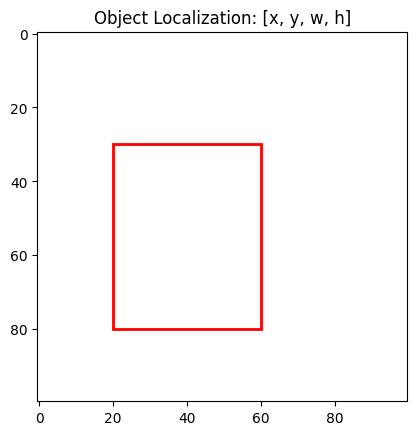

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Define a sample 100x100 blank image
img = np.ones((100, 100, 3))

# Define a bounding box [x, y, w, h]
# For this visualization, we'll assume [top-left x, top-left y, width, height]
bbox = [20, 30, 40, 50] 

fig, ax = plt.subplots()
ax.imshow(img)

# Create a Rectangle patch
rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=2, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)
plt.title("Object Localization: [x, y, w, h]")
plt.show()

## YOLO (You Only Look Once)
YOLO is famous because it treats detection as a single regression problem, making it fast enough for live video. We typically use the `ultralytics` library to run modern YOLO models like YOLOv8 through YOLOv11.

In [3]:
# Note: You would normally run !pip install ultralytics
from ultralytics import YOLO

# Load a pre-trained YOLOv11 nano model[cite: 1]
# 'n' stands for nano (the fastest/lightest version)
try:
    model = YOLO('yolo11n.pt') 
    print("YOLOv11 model loaded successfully.")
except:
    print("Model file not found. Ensure you have an internet connection to download.")

# To run detection on an image:
# results = model('path/to/image.jpg')
# results[0].show()

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\zarya\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv11 model loaded successfully.


## Metrics: Intersection over Union (IoU)
To know if our model is "correct," we calculate the **IoU**. If the predicted box overlaps almost perfectly with the real box, the IoU is close to 1.0.

In [4]:
def calculate_iou(box1, box2):
    """
    Calculates Intersection over Union (IoU) for two boxes [x1, y1, x2, y2].
    """
    # Determine the coordinates of the intersection rectangle
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    
    # Calculate Union Area
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = area1 + area2 - intersection_area
    
    return intersection_area / union_area

# Example
ground_truth = [10, 10, 50, 50]
prediction = [15, 15, 55, 55]

iou_score = calculate_iou(ground_truth, prediction)
print(f"IoU Score: {iou_score:.4f}")

IoU Score: 0.6203


---
## Student Task: The Real-Time Security Bot

**Topic:** Module 7 (Object Detection)

**Goal:** Detect multiple people and objects in a live video stream.

**Requirements:**
1. Install the `ultralytics` and `opencv-python` libraries.
2. Use the YOLOv11 nano model (`yolo11n.pt`).
3. Set the model to run at a speed of >20 FPS (Frames Per Second).

**Deliverable:**
* A script that opens your webcam, performs real-time detection, and draws bounding boxes with confidence scores on the screen. 
* Press 'q' to exit the video stream.

In [7]:
# TASK: Complete the script for real-time detection
import cv2
from ultralytics import YOLO

# 1. Load model
model = YOLO('yolo11n.pt')

# 2. Open Webcam
cap = cv2.VideoCapture(0)

# 3. Loop through frames
while cap.isOpened():
    success, frame = cap.read()
    if success:
        results = model(frame) # Run detection
        annotated_frame = results[0].plot() # Draw boxes
        cv2.imshow("YOLO11 Real-Time Detection", annotated_frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

print("Security Bot logic ready. Uncomment and run on your local machine with a webcam!")


0: 480x640 1 person, 4 chairs, 1 laptop, 291.3ms
Speed: 5.6ms preprocess, 291.3ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 3 chairs, 1 laptop, 306.5ms
Speed: 7.2ms preprocess, 306.5ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 3 chairs, 1 laptop, 277.0ms
Speed: 5.4ms preprocess, 277.0ms inference, 4.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 3 chairs, 1 laptop, 285.0ms
Speed: 5.0ms preprocess, 285.0ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 3 chairs, 1 laptop, 229.5ms
Speed: 3.7ms preprocess, 229.5ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 3 chairs, 1 laptop, 221.2ms
Speed: 32.3ms preprocess, 221.2ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 3 chairs, 1 laptop, 232.4ms
Speed: 4.1ms preprocess, 232.4ms inference, 1.6ms postprocess

KeyboardInterrupt: 